# Homework 6: Pandas DataFrame II

**Student Name:** 

**Student ID:**

**Date:** 

## Assignment Overview
This homework assignment tests your understanding of advanced Pandas DataFrame operations including grouping, merging, and data transformation.

## Learning Objectives
- Master DataFrame grouping and aggregation
- Perform data merging and joining
- Use pivot tables and reshaping
- Apply advanced data transformation techniques
- Handle time series data

## Instructions
1. Complete all exercises in order
2. Run all code cells and ensure they execute without errors
3. Answer all written questions thoroughly
4. Submit your completed notebook

---

## Exercise 1: Grouping and Aggregation (20 points)

**Task:** Perform grouping and aggregation operations on DataFrames.

**Requirements:**
- Group data by different criteria
- Apply aggregation functions
- Use groupby operations
- Demonstrate advanced grouping techniques


In [2]:
# TODO: Complete the following tasks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# 1. Create sample datasets for analysis
print("=== CREATING SAMPLE DATASETS ===")

# Create sales data
sales_data = {
    'Date': pd.date_range('2023-01-01', periods=100, freq='D'),
    'Product': np.random.choice(['Laptop', 'Phone', 'Tablet', 'Headphones'], 100),
    'Category': np.random.choice(['Electronics', 'Accessories'], 100),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 100),
    'Salesperson': np.random.choice(['Alice', 'Bob', 'Charlie', 'Diana'], 100),
    'Quantity': np.random.randint(1, 10, 100),
    'Price': np.random.uniform(50, 1000, 100),
    'Customer_Rating': np.random.uniform(3.0, 5.0, 100)
}

df_sales = pd.DataFrame(sales_data)
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['Price']

print(f"Sales DataFrame shape: {df_sales.shape}")
print(f"\nFirst 5 rows:")
print(df_sales.head())

# Create employee data
employee_data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Department': ['Sales', 'Sales', 'Marketing', 'Sales'],
    'Experience_Years': [5, 3, 7, 2],
    'Salary': [75000, 65000, 80000, 55000],
    'Hire_Date': pd.to_datetime(['2018-03-15', '2020-06-20', '2016-01-10', '2021-09-05'])
}

df_employees = pd.DataFrame(employee_data)

print(f"\nEmployee DataFrame:")
print(df_employees)

# 2. Basic Grouping Operations
print(f"\n=== BASIC GROUPING OPERATIONS ===")

# TODO: Group by single column
print("Grouping by Product:")
product_groups = df_sales.groupby('Product')
print(f"Number of groups: {len(product_groups)}")
print(f"Group names: {list(product_groups.groups.keys())}")

# Basic aggregation
product_summary = product_groups.agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Customer_Rating': 'mean'
}).round(2)

print(f"\nProduct Summary:")
print(product_summary)

# TODO: Group by multiple columns
print(f"\nGrouping by Product and Region:")
multi_groups = df_sales.groupby(['Product', 'Region'])
multi_summary = multi_groups.agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Customer_Rating': 'mean'
}).round(2)

print(f"Multi-group Summary (first 10 rows):")
print(multi_summary.head(10))

# 3. Advanced Aggregation Functions
print(f"\n=== ADVANCED AGGREGATION FUNCTIONS ===")

# TODO: Custom aggregation functions
def custom_stats(group):
    return pd.Series({
        'count': len(group),
        'total_revenue': group['Revenue'].sum(),
        'avg_rating': group['Customer_Rating'].mean(),
        'max_quantity': group['Quantity'].max(),
        'min_price': group['Price'].min()
    })

# Apply custom aggregation
region_stats = df_sales.groupby('Region').apply(custom_stats).round(2)
print(f"Custom Statistics by Region:")
print(region_stats)

# TODO: Multiple aggregation functions
print(f"\nMultiple Aggregation Functions:")
agg_functions = {
    'Quantity': ['sum', 'mean', 'std'],
    'Revenue': ['sum', 'mean', 'max'],
    'Customer_Rating': ['mean', 'min', 'max']
}

multi_agg = df_sales.groupby('Category').agg(agg_functions).round(2)
print(multi_agg)

# 4. Groupby with Transform and Filter
print(f"\n=== GROUPBY WITH TRANSFORM AND FILTER ===")

# TODO: Transform operations
df_sales['Revenue_Per_Group'] = df_sales.groupby('Product')['Revenue'].transform('sum')
df_sales['Avg_Rating_Per_Region'] = df_sales.groupby('Region')['Customer_Rating'].transform('mean')

print(f"DataFrame with transform operations (first 5 rows):")
print(df_sales[['Product', 'Revenue', 'Revenue_Per_Group', 'Region', 'Customer_Rating', 'Avg_Rating_Per_Region']].head())

# TODO: Filter operations
def high_revenue_groups(group):
    return group['Revenue'].sum() > 5000

high_revenue = df_sales.groupby('Product').filter(high_revenue_groups)
print(f"\nProducts with total revenue > 5000:")
print(f"Unique products: {high_revenue['Product'].unique()}")
print(f"Number of records: {len(high_revenue)}")

# 5. Pivot Tables
print(f"\n=== PIVOT TABLES ===")

# TODO: Create pivot tables
pivot_quantity = df_sales.pivot_table(
    values='Quantity',
    index='Product',
    columns='Region',
    aggfunc='sum',
    fill_value=0
)

print(f"Quantity by Product and Region:")
print(pivot_quantity)

# TODO: Multi-level pivot table
pivot_multi = df_sales.pivot_table(
    values=['Quantity', 'Revenue'],
    index=['Product', 'Category'],
    columns='Region',
    aggfunc={'Quantity': 'sum', 'Revenue': 'mean'},
    fill_value=0
)

print(f"\nMulti-level Pivot Table (first 5 rows):")
print(pivot_multi.head())

# 6. Data Merging and Joining
print(f"\n=== DATA MERGING AND JOINING ===")

# TODO: Merge sales data with employee data
# First, create a mapping from salesperson to employee data
salesperson_mapping = df_employees.set_index('Name')[['Department', 'Experience_Years', 'Salary']]
df_sales_merged = df_sales.merge(salesperson_mapping, left_on='Salesperson', right_index=True, how='left')

print(f"Sales data merged with employee data (first 5 rows):")
print(df_sales_merged[['Salesperson', 'Department', 'Experience_Years', 'Salary', 'Revenue']].head())

# TODO: Different types of joins
# Create a small dataset for demonstration
df_products = pd.DataFrame({
    'Product': ['Laptop', 'Phone', 'Tablet', 'Headphones', 'Mouse'],
    'Category': ['Electronics', 'Electronics', 'Electronics', 'Accessories', 'Accessories'],
    'Cost': [400, 300, 200, 50, 25]
})

print(f"\nProducts DataFrame:")
print(df_products)

# Inner join
inner_join = df_sales.merge(df_products, on='Product', how='inner')
print(f"\nInner join shape: {inner_join.shape}")

# Left join
left_join = df_sales.merge(df_products, on='Product', how='left')
print(f"Left join shape: {left_join.shape}")

# Right join
right_join = df_sales.merge(df_products, on='Product', how='right')
print(f"Right join shape: {right_join.shape}")

# 7. Data Reshaping
print(f"\n=== DATA RESHAPING ===")

# TODO: Melt operation
melted_data = df_sales.melt(
    id_vars=['Date', 'Product', 'Region'],
    value_vars=['Quantity', 'Revenue', 'Customer_Rating'],
    var_name='Metric',
    value_name='Value'
)

print(f"Melted data (first 10 rows):")
print(melted_data.head(10))

# TODO: Pivot operation (reverse of melt)
pivoted_data = melted_data.pivot_table(
    index=['Date', 'Product', 'Region'],
    columns='Metric',
    values='Value',
    fill_value=0
).reset_index()

print(f"\nPivoted data (first 5 rows):")
print(pivoted_data.head())

# 8. Time Series Operations
print(f"\n=== TIME SERIES OPERATIONS ===")

# TODO: Set date as index
df_sales_time = df_sales.set_index('Date')
print(f"DataFrame with Date as index:")
print(df_sales_time.head())

# TODO: Resample by different time periods
daily_revenue = df_sales_time['Revenue'].resample('D').sum()
weekly_revenue = df_sales_time['Revenue'].resample('W').sum()
monthly_revenue = df_sales_time['Revenue'].resample('M').sum()

print(f"\nDaily Revenue (first 5 days):")
print(daily_revenue.head())

print(f"\nWeekly Revenue:")
print(weekly_revenue.head())

print(f"\nMonthly Revenue:")
print(monthly_revenue.head())

# TODO: Rolling window operations
df_sales_time['Revenue_7day_avg'] = df_sales_time['Revenue'].rolling(window=7).mean()
df_sales_time['Revenue_30day_avg'] = df_sales_time['Revenue'].rolling(window=30).mean()

print(f"\nDataFrame with rolling averages (last 5 rows):")
print(df_sales_time[['Revenue', 'Revenue_7day_avg', 'Revenue_30day_avg']].tail())


=== CREATING SAMPLE DATASETS ===
Sales DataFrame shape: (100, 9)

First 5 rows:
        Date     Product     Category Region Salesperson  Quantity  \
0 2023-01-01      Tablet  Electronics   East       Alice         8   
1 2023-01-02  Headphones  Accessories   West       Alice         4   
2 2023-01-03      Laptop  Accessories   East     Charlie         1   
3 2023-01-04      Tablet  Accessories  North         Bob         8   
4 2023-01-05      Tablet  Accessories   West         Bob         4   

        Price  Customer_Rating      Revenue  
0  197.289536         4.095944  1578.316287  
1  982.748844         3.846942  3930.995376  
2  846.986827         4.137041   846.986827  
3  867.384387         4.151849  6939.075099  
4  287.738792         4.463296  1150.955170  

Employee DataFrame:
      Name Department  Experience_Years  Salary  Hire_Date
0    Alice      Sales                 5   75000 2018-03-15
1      Bob      Sales                 3   65000 2020-06-20
2  Charlie  Marketing    

/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_66889/1385294248.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_stats = df_sales.groupby('Region').apply(custom_stats).round(2)
/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_66889/1385294248.py:223: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df_sales_time['Revenue'].resample('M').sum()


**Question 1.1:** What is the difference between `groupby().agg()` and `groupby().apply()`?

**Answer:** [Your answer here]

**Question 1.2:** When would you use `transform()` vs `filter()` in groupby operations?

**Answer:** [Your answer here]

**Question 1.3:** What are the advantages of using pivot tables over groupby operations?

**Answer:** [Your answer here]


---

## Exercise 2: Data Merging and Joining (20 points)

**Task:** Perform various data merging and joining operations.

**Requirements:**
- Merge DataFrames using different join types
- Handle missing values in merged data
- Use different merge keys and strategies
- Demonstrate complex merging scenarios


In [4]:
# TODO: Complete the following merging exercises

# 1. Create additional datasets for merging
print("=== CREATING DATASETS FOR MERGING ===")

# Customer data
customer_data = {
    'Customer_ID': [1, 2, 3, 4, 5, 6],
    'Name': ['Alice Johnson', 'Bob Smith', 'Charlie Brown', 'Diana Prince', 'Eve Wilson', 'Frank Miller'],
    'Email': ['alice@email.com', 'bob@email.com', 'charlie@email.com', 'diana@email.com', 'eve@email.com', 'frank@email.com'],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia'],
    'Registration_Date': pd.to_datetime(['2022-01-15', '2022-03-20', '2022-02-10', '2022-04-05', '2022-05-12', '2022-06-18'])
}

df_customers = pd.DataFrame(customer_data)

# Order data
order_data = {
    'Order_ID': [101, 102, 103, 104, 105, 106, 107, 108],
    'Customer_ID': [1, 2, 1, 3, 4, 2, 5, 6],
    'Product': ['Laptop', 'Phone', 'Tablet', 'Headphones', 'Laptop', 'Phone', 'Tablet', 'Headphones'],
    'Order_Date': pd.to_datetime(['2023-01-15', '2023-01-20', '2023-02-01', '2023-02-10', '2023-02-15', '2023-03-01', '2023-03-10', '2023-03-20']),
    'Amount': [1200, 800, 600, 150, 1100, 750, 550, 140]
}

df_orders = pd.DataFrame(order_data)

# Product details
product_details = {
    'Product': ['Laptop', 'Phone', 'Tablet', 'Headphones', 'Mouse', 'Keyboard'],
    'Category': ['Electronics', 'Electronics', 'Electronics', 'Accessories', 'Accessories', 'Accessories'],
    'Brand': ['TechCorp', 'PhoneInc', 'TabletPro', 'SoundMax', 'ClickTech', 'TypeFast'],
    'Warranty_Years': [2, 1, 2, 1, 1, 1],
    'Weight_kg': [2.5, 0.2, 0.8, 0.3, 0.1, 0.5]
}

df_products = pd.DataFrame(product_details)

print(f"Customers DataFrame:")
print(df_customers)
print(f"\nOrders DataFrame:")
print(df_orders)
print(f"\nProducts DataFrame:")
print(df_products)

# 2. Basic Merging Operations
print(f"\n=== BASIC MERGING OPERATIONS ===")

# TODO: Inner join
print("Inner Join - Customers and Orders:")
inner_merge = df_customers.merge(df_orders, on='Customer_ID', how='inner')
print(f"Shape: {inner_merge.shape}")
print(inner_merge.head())

# TODO: Left join
print(f"\nLeft Join - Customers and Orders:")
left_merge = df_customers.merge(df_orders, on='Customer_ID', how='left')
print(f"Shape: {left_merge.shape}")
print(f"Missing values in Order_ID: {left_merge['Order_ID'].isnull().sum()}")

# TODO: Right join
print(f"\nRight Join - Orders and Customers:")
right_merge = df_orders.merge(df_customers, on='Customer_ID', how='right')
print(f"Shape: {right_merge.shape}")

# TODO: Outer join
print(f"\nOuter Join - Customers and Orders:")
outer_merge = df_customers.merge(df_orders, on='Customer_ID', how='outer')
print(f"Shape: {outer_merge.shape}")
print(f"Missing values in Customer_ID: {outer_merge['Customer_ID'].isnull().sum()}")

# 3. Advanced Merging Scenarios
print(f"\n=== ADVANCED MERGING SCENARIOS ===")

# TODO: Merge with different column names
print("Merging with different column names:")
df_orders_renamed = df_orders.rename(columns={'Product': 'Product_Name'})
merge_different_cols = df_orders_renamed.merge(
    df_products, 
    left_on='Product_Name', 
    right_on='Product', 
    how='left'
)
print(f"Shape: {merge_different_cols.shape}")
print(merge_different_cols[['Order_ID', 'Product_Name', 'Brand', 'Category']].head())

# TODO: Merge with multiple keys
print(f"\nMerging with multiple keys:")
# Create a dataset with multiple keys
df_orders_multi = df_orders.copy()
df_orders_multi['Order_Month'] = df_orders_multi['Order_Date'].dt.month

df_customers_multi = df_customers.copy()
df_customers_multi['Registration_Month'] = df_customers_multi['Registration_Date'].dt.month

multi_key_merge = df_orders_multi.merge(
    df_customers_multi, 
    left_on=['Customer_ID', 'Order_Month'],
    right_on=['Customer_ID', 'Registration_Month'], 
    how='left'
)
print(f"Shape: {multi_key_merge.shape}")
print(multi_key_merge[['Order_ID', 'Customer_ID', 'Order_Month', 'Name', 'City']].head())

# 4. Handling Missing Values in Merged Data
print(f"\n=== HANDLING MISSING VALUES ===")

# TODO: Identify and handle missing values
print("Missing values analysis:")
print(f"Left merge missing values:")
print(left_merge.isnull().sum())

# TODO: Fill missing values
left_merge_filled = left_merge.copy()
left_merge_filled['Order_ID'] = left_merge_filled['Order_ID'].fillna(0)
left_merge_filled['Product'] = left_merge_filled['Product'].fillna('No Order')
left_merge_filled['Amount'] = left_merge_filled['Amount'].fillna(0)

print(f"\nAfter filling missing values:")
print(left_merge_filled.isnull().sum())

# 5. Complex Merging Scenarios
print(f"\n=== COMPLEX MERGING SCENARIOS ===")

# TODO: Merge multiple DataFrames
print("Merging multiple DataFrames:")
# First merge: orders with customers
orders_customers = df_orders.merge(df_customers, on='Customer_ID', how='left')

# Second merge: add product details
complete_data = orders_customers.merge(df_products, on='Product', how='left')

print(f"Complete merged data shape: {complete_data.shape}")
print(f"Columns: {list(complete_data.columns)}")
print(complete_data.head())

# TODO: Merge with aggregation
print(f"\nMerging with aggregation:")
# Aggregate orders by customer
customer_totals = df_orders.groupby('Customer_ID').agg({
    'Order_ID': 'count',
    'Amount': ['sum', 'mean', 'max']
}).round(2)

# Flatten column names
customer_totals.columns = ['_'.join(col).strip() for col in customer_totals.columns]
customer_totals = customer_totals.reset_index()

# Merge with customer data
customer_summary = df_customers.merge(customer_totals, on='Customer_ID', how='left')
print(f"Customer summary with order statistics:")
print(customer_summary)

# 6. Merge Performance and Best Practices
print(f"\n=== MERGE PERFORMANCE AND BEST PRACTICES ===")

# TODO: Demonstrate merge performance
import time

# Large dataset simulation
large_customers = pd.concat([df_customers] * 1000, ignore_index=True)
large_orders = pd.concat([df_orders] * 1000, ignore_index=True)

print(f"Large datasets created:")
print(f"Customers shape: {large_customers.shape}")
print(f"Orders shape: {large_orders.shape}")

# Time the merge operation
start_time = time.time()
large_merge = large_customers.merge(large_orders, on='Customer_ID', how='inner')
end_time = time.time()

print(f"Merge completed in {end_time - start_time:.4f} seconds")
print(f"Result shape: {large_merge.shape}")

# TODO: Memory usage optimization
print(f"\nMemory optimization tips:")
print(f"Original customers memory usage: {df_customers.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"Original orders memory usage: {df_orders.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Convert to appropriate data types
df_customers_optimized = df_customers.copy()
df_customers_optimized['Customer_ID'] = df_customers_optimized['Customer_ID'].astype('int32')
df_customers_optimized['Name'] = df_customers_optimized['Name'].astype('category')

print(f"Optimized customers memory usage: {df_customers_optimized.memory_usage(deep=True).sum() / 1024:.2f} KB")


=== CREATING DATASETS FOR MERGING ===
Customers DataFrame:
   Customer_ID           Name              Email          City  \
0            1  Alice Johnson    alice@email.com      New York   
1            2      Bob Smith      bob@email.com   Los Angeles   
2            3  Charlie Brown  charlie@email.com       Chicago   
3            4   Diana Prince    diana@email.com       Houston   
4            5     Eve Wilson      eve@email.com       Phoenix   
5            6   Frank Miller    frank@email.com  Philadelphia   

  Registration_Date  
0        2022-01-15  
1        2022-03-20  
2        2022-02-10  
3        2022-04-05  
4        2022-05-12  
5        2022-06-18  

Orders DataFrame:
   Order_ID  Customer_ID     Product Order_Date  Amount
0       101            1      Laptop 2023-01-15    1200
1       102            2       Phone 2023-01-20     800
2       103            1      Tablet 2023-02-01     600
3       104            3  Headphones 2023-02-10     150
4       105            4 

---

## Exercise 3: Data Visualization and Analysis (20 points)

**Task:** Create visualizations to analyze the grouped and merged data.

**Requirements:**
- Create charts for grouped data
- Visualize merged data relationships
- Use appropriate plot types for different data types
- Customize plots for better presentation


=== VISUALIZING GROUPED DATA ===


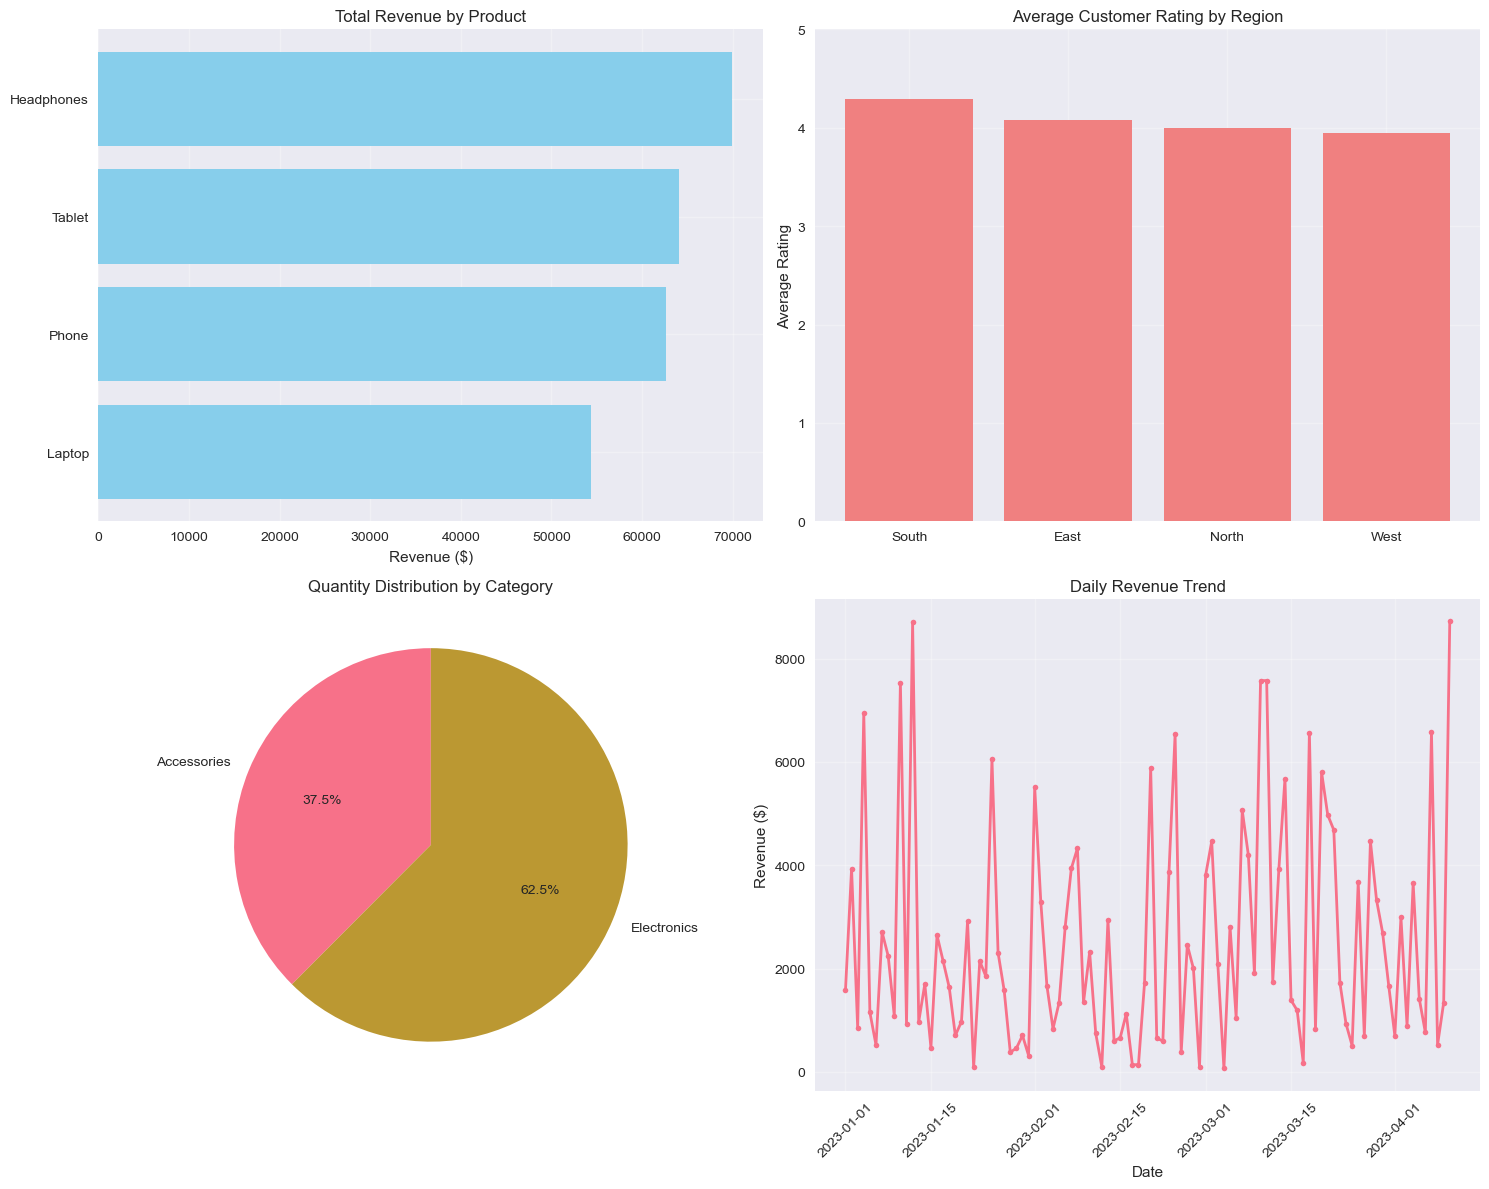


=== VISUALIZING MERGED DATA ===


/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_66889/48981594.py:86: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  customer_timeline = df_customers.set_index('Registration_Date').resample('M').size().cumsum()


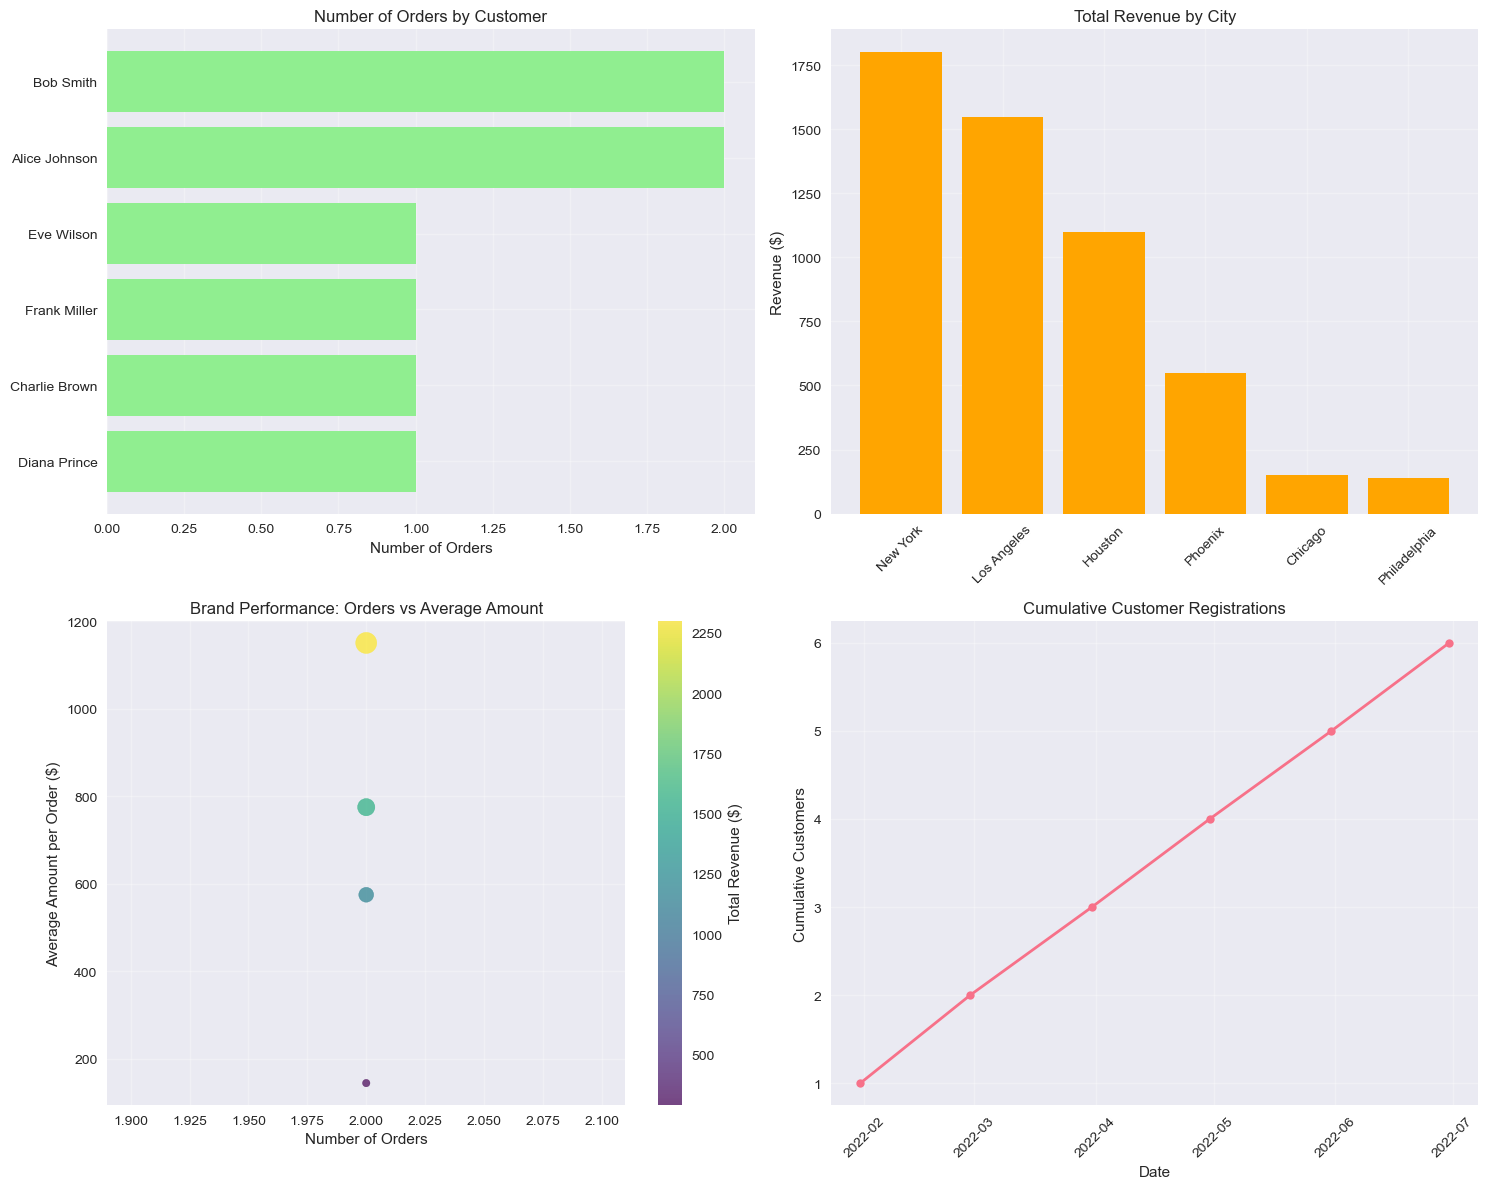


=== ADVANCED VISUALIZATIONS ===


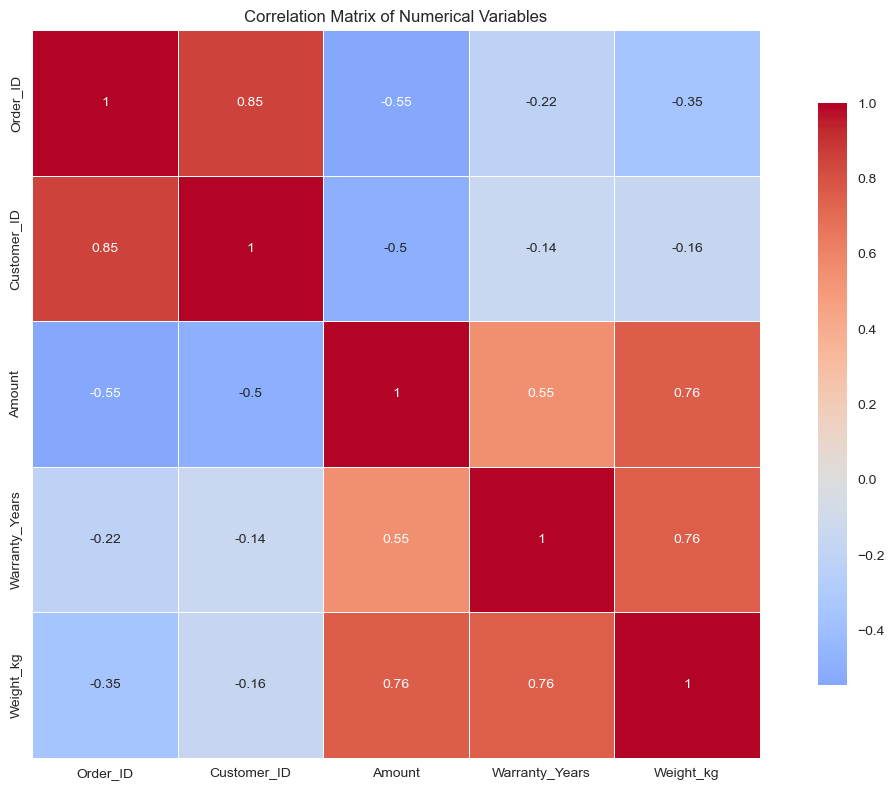

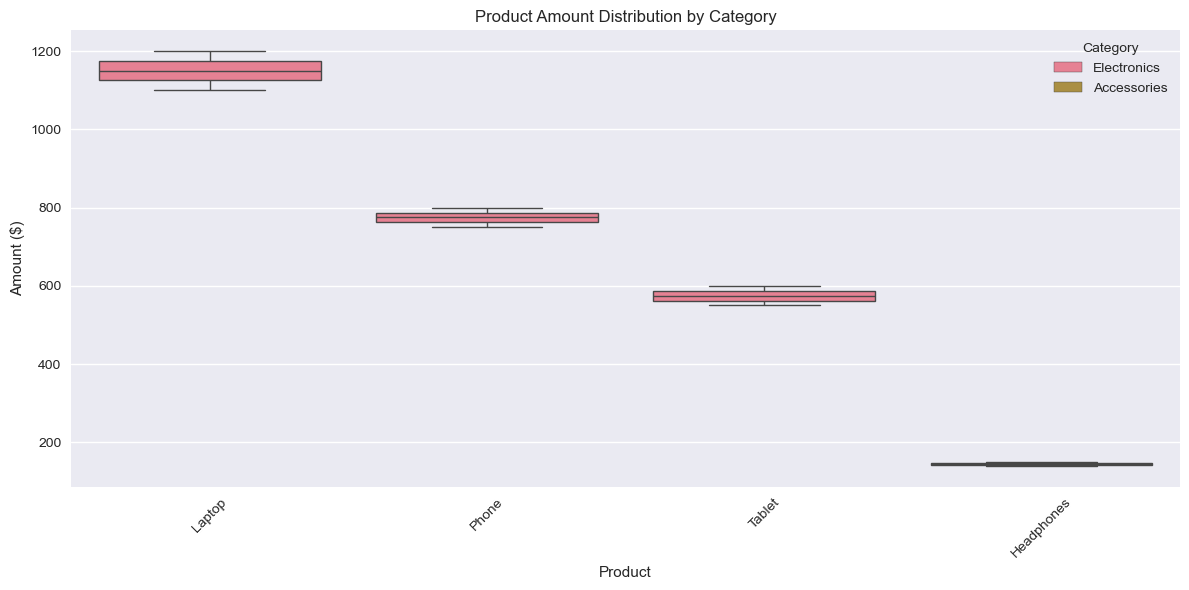

<Figure size 1500x800 with 0 Axes>

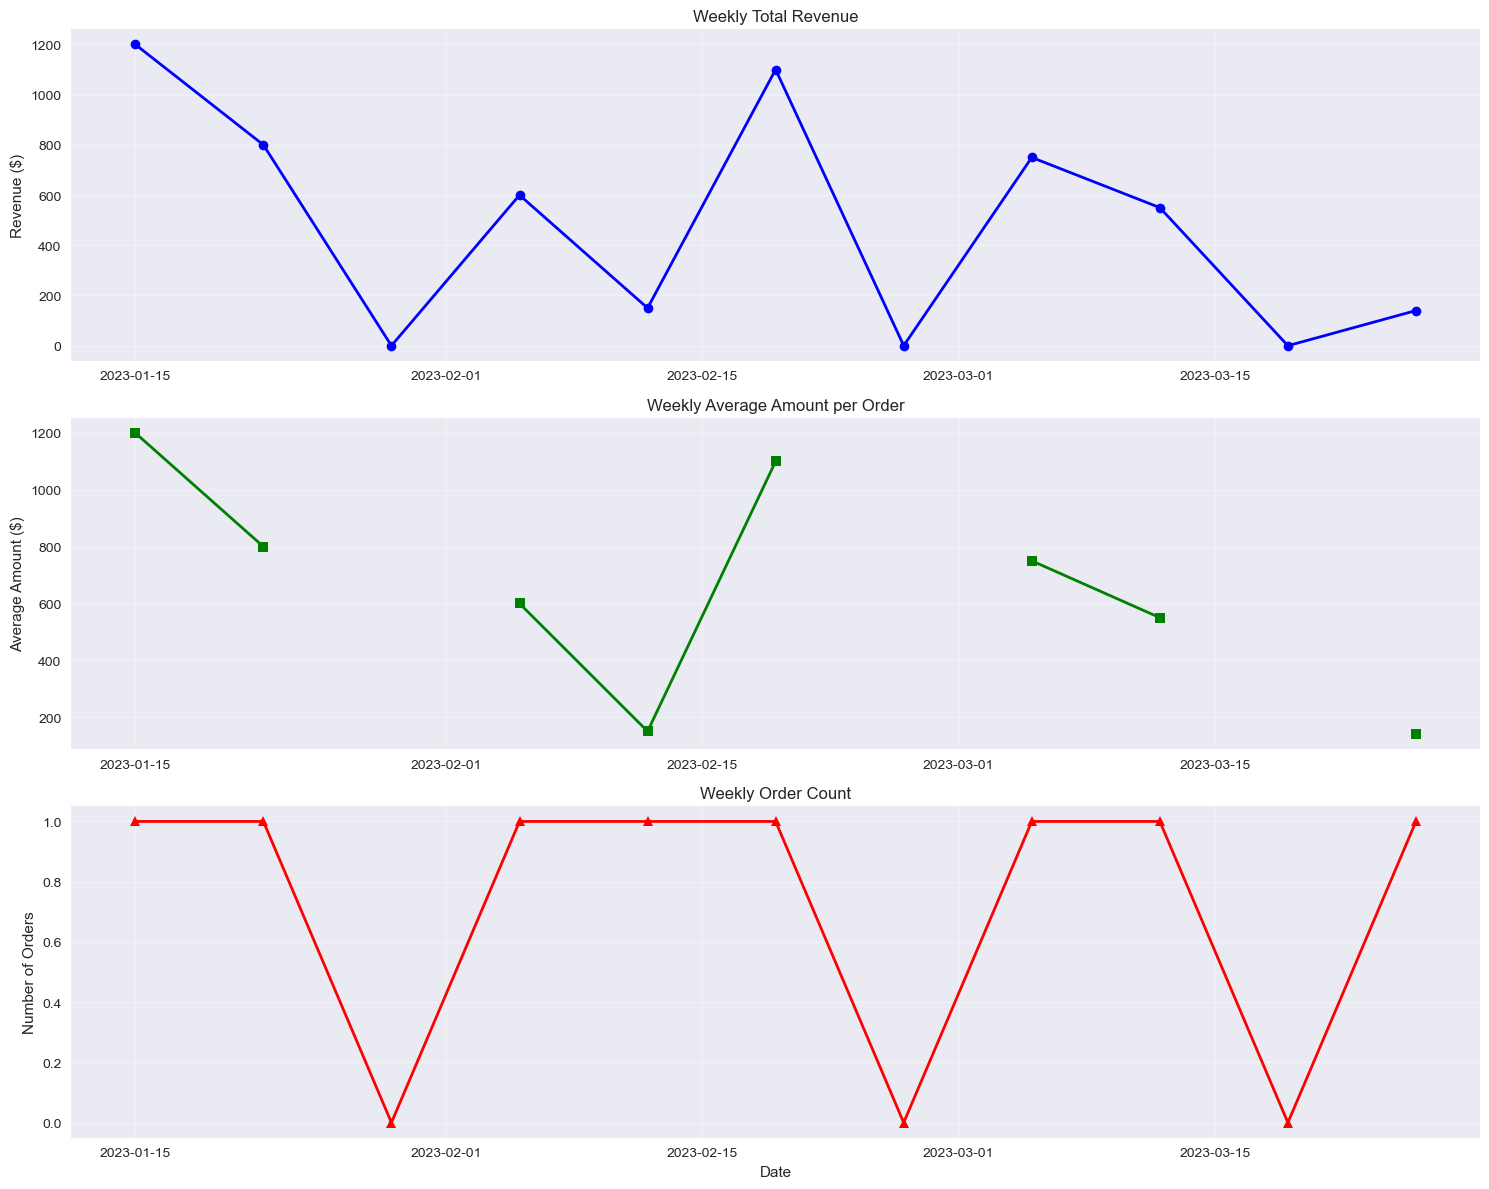


=== INTERACTIVE ANALYSIS ===
Summary Statistics for Complete Dataset:
Total Revenue: $5,290.00
Average Order Amount: $661.25
Total Orders: 8
Total Customers: 6

Top 5 Customers by Revenue:
1. Alice Johnson: $1,800.00
2. Bob Smith: $1,550.00
3. Diana Prince: $1,100.00
4. Eve Wilson: $550.00
5. Charlie Brown: $150.00

Top 5 Products by Revenue:
1. Laptop: $2,300.00
2. Phone: $1,550.00
3. Tablet: $1,150.00
4. Headphones: $290.00

Regional Analysis:
              Amount_sum  Amount_mean  Amount_count  Weight_kg_sum
City                                                              
Chicago              150        150.0             1            0.3
Houston             1100       1100.0             1            2.5
Los Angeles         1550        775.0             2            0.4
New York            1800        900.0             2            3.3
Philadelphia         140        140.0             1            0.3
Phoenix              550        550.0             1            0.8

🎉 All visual

In [7]:
# TODO: Complete the following visualization exercises

# 1. Set up plotting style
from typing import Any, Hashable


plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Visualize Grouped Data
print("=== VISUALIZING GROUPED DATA ===")

# TODO: Create subplots for different analyses
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Revenue by Product
product_revenue = df_sales.groupby('Product')['Revenue'].sum().sort_values(ascending=True)
axes[0, 0].barh(product_revenue.index, product_revenue.values, color='skyblue')
axes[0, 0].set_title('Total Revenue by Product')
axes[0, 0].set_xlabel('Revenue ($)')
axes[0, 0].grid(True, alpha=0.3)

# Average Rating by Region
region_rating = df_sales.groupby('Region')['Customer_Rating'].mean().sort_values(ascending=False)
axes[0, 1].bar(region_rating.index, region_rating.values, color='lightcoral')
axes[0, 1].set_title('Average Customer Rating by Region')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_ylim(0, 5)
axes[0, 1].grid(True, alpha=0.3)

# Quantity distribution by Category
category_quantity = df_sales.groupby('Category')['Quantity'].sum()
axes[1, 0].pie(category_quantity.values, labels=category_quantity.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Quantity Distribution by Category')

# Revenue trend over time
daily_revenue = df_sales.groupby('Date')['Revenue'].sum()
axes[1, 1].plot(daily_revenue.index, daily_revenue.values, marker='o', linewidth=2, markersize=4)
axes[1, 1].set_title('Daily Revenue Trend')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Revenue ($)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Visualize Merged Data
print("\n=== VISUALIZING MERGED DATA ===")

# TODO: Create visualizations for merged data
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Customer order count
customer_orders = complete_data.groupby('Name')['Order_ID'].count().sort_values(ascending=True)
axes[0, 0].barh(customer_orders.index, customer_orders.values, color='lightgreen')
axes[0, 0].set_title('Number of Orders by Customer')
axes[0, 0].set_xlabel('Number of Orders')
axes[0, 0].grid(True, alpha=0.3)

# Revenue by City
city_revenue = complete_data.groupby('City')['Amount'].sum().sort_values(ascending=False)
axes[0, 1].bar(city_revenue.index, city_revenue.values, color='orange')
axes[0, 1].set_title('Total Revenue by City')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Product performance by brand
brand_performance = complete_data.groupby('Brand')['Amount'].agg(['sum', 'count']).reset_index()
brand_performance['avg_amount'] = brand_performance['sum'] / brand_performance['count']

scatter = axes[1, 0].scatter(brand_performance['count'], brand_performance['avg_amount'], 
                            s=brand_performance['sum']/10, alpha=0.7, c=brand_performance['sum'], 
                            cmap='viridis')
axes[1, 0].set_title('Brand Performance: Orders vs Average Amount')
axes[1, 0].set_xlabel('Number of Orders')
axes[1, 0].set_ylabel('Average Amount per Order ($)')
axes[1, 0].grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Total Revenue ($)')

# Customer registration timeline
customer_timeline = df_customers.set_index('Registration_Date').resample('M').size().cumsum()
axes[1, 1].plot(customer_timeline.index, customer_timeline.values, marker='o', linewidth=2, markersize=6)
axes[1, 1].set_title('Cumulative Customer Registrations')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Cumulative Customers')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Advanced Visualizations
print("\n=== ADVANCED VISUALIZATIONS ===")

# TODO: Create heatmap for correlation analysis
plt.figure(figsize=(12, 8))

# Calculate correlation matrix for numerical columns
numerical_cols = complete_data.select_dtypes(include=[np.number]).columns
correlation_matrix = complete_data[numerical_cols].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# TODO: Create box plot for product analysis
plt.figure(figsize=(12, 6))
sns.boxplot(data=complete_data, x='Product', y='Amount', hue='Category')
plt.title('Product Amount Distribution by Category')
plt.xlabel('Product')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

# TODO: Create time series analysis
plt.figure(figsize=(15, 8))

# Create time series data
time_series_data = complete_data.set_index('Order_Date').resample('W').agg({
    'Amount': ['sum', 'mean', 'count'],
    'Weight_kg': 'sum'
}).round(2)

# Flatten column names
time_series_data.columns = ['_'.join(col).strip() for col in time_series_data.columns]

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

# Weekly revenue
ax1.plot(time_series_data.index, time_series_data['Amount_sum'], marker='o', linewidth=2, color='blue')
ax1.set_title('Weekly Total Revenue')
ax1.set_ylabel('Revenue ($)')
ax1.grid(True, alpha=0.3)

# Weekly average amount
ax2.plot(time_series_data.index, time_series_data['Amount_mean'], marker='s', linewidth=2, color='green')
ax2.set_title('Weekly Average Amount per Order')
ax2.set_ylabel('Average Amount ($)')
ax2.grid(True, alpha=0.3)

# Weekly order count
ax3.plot(time_series_data.index, time_series_data['Amount_count'], marker='^', linewidth=2, color='red')
ax3.set_title('Weekly Order Count')
ax3.set_xlabel('Date')
ax3.set_ylabel('Number of Orders')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Interactive Analysis
print("\n=== INTERACTIVE ANALYSIS ===")

# TODO: Create summary statistics
print("Summary Statistics for Complete Dataset:")
print(f"Total Revenue: ${complete_data['Amount'].sum():,.2f}")
print(f"Average Order Amount: ${complete_data['Amount'].mean():.2f}")
print(f"Total Orders: {complete_data['Order_ID'].nunique()}")
print(f"Total Customers: {complete_data['Customer_ID'].nunique()}")

# TODO: Top performers analysis
print(f"\nTop 5 Customers by Revenue:")
top_customers = complete_data.groupby('Name')['Amount'].sum().sort_values(ascending=False).head()
for i, (name, amount) in enumerate(top_customers.items(), 1):
    print(f"{i}. {name}: ${amount:,.2f}")

print(f"\nTop 5 Products by Revenue:")
top_products = complete_data.groupby('Product')['Amount'].sum().sort_values(ascending=False).head()
for i, (product, amount) in enumerate[tuple[Hashable, Any]](top_products.items(), 1):
    print(f"{i}. {product}: ${amount:,.2f}")

# TODO: Regional analysis
print(f"\nRegional Analysis:")
regional_stats = complete_data.groupby('City').agg({
    'Amount': ['sum', 'mean', 'count'],
    'Weight_kg': 'sum'
}).round(2)

regional_stats.columns = ['_'.join(col).strip() for col in regional_stats.columns]
print(regional_stats)

print(f"\n🎉 All visualization exercises completed!")
